# Etap 2: Raport z Modelowania i Ewaluacji
**Projekt:** Detekcja celowo zawyżonych cen w ofertach noclegowych

Zgodnie z wymaganiami Canvas oraz specyfikacją Etapu 2 (punkt b.i), niniejszy notatnik przedstawia proces budowy oraz ewaluacji dwóch modeli analitycznych:
1. **Model Bazowy (Baseline):** Uczenie nienadzorowane przy użyciu algorytmu *Isolation Forest*.
2. **Model Docelowy (Advanced):** Najlepszy model stworzony za pomocą uczenia nadzorowanego przy użyciu *Random Forest*, *ExtraTrees* i *XGBoost*, poddane procesowi optymalizacji hiperparametrów (RandomizedSearchCV) oraz ocenie za pomocą zagnieżdżonej kroswalidacji.

**Kryteria sukcesu (z Canvasa):**
* **Swoistość (Specificity):** $\ge 90\%$ (Minimalizacja kosztu fałszywych alarmów - FP).
* **Czułość (Recall):** $\ge 30\%$ (Wykrywanie co najmniej części faktycznych anomalii - TP).

In [16]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    classification_report,
    make_scorer,
)

from sklearn.ensemble import IsolationForest, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    make_scorer
)
from scipy.stats import randint

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Wczytanie Zbioru Danych
Używamy przygotowanego wcześniej zbioru produkcyjnego. Zmienną docelową (Target) jest `overpriced`, która została wygenerowana jako proxy dla zawyżonych cen (brak rezerwacji + cena powyżej normy rynkowej).

In [17]:
# ============================================================
# LOAD DATA
# ============================================================

TARGET = "overpriced"

df = pd.read_csv("data/production_dataset.csv")

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Rozmiar zbioru: {df.shape}")
print("\nRozkład zmiennej celu (Target):")
print(y.value_counts(normalize=True).apply(lambda x: f"{x*100:.2f}%"))

Rozmiar zbioru: (1448, 14)

Rozkład zmiennej celu (Target):
overpriced
0    85.36%
1    14.64%
Name: proportion, dtype: object


## 2. Model Bazowy - Isolation Forest
Jako najprostszy model bazowy wykorzystujemy *Isolation Forest*. Algorytm ten jest standardowym podejściem w nienadzorowanym wykrywaniu anomalii. Izoluje on obserwacje poprzez losowy podział przestrzeni cech - obserwacje odstające są izolowane szybciej (wymagają mniejszej liczby podziałów).

*Uwaga: Zwracane przez IF predykcje to -1 (anomalia) oraz 1 (obserwacja normalna). Mapujemy je na naszą konwencję 1 (overpriced) i 0 (normal).*

--- Wyniki Modelu Bazowego (Isolation Forest) ---
Swoistość (Specificity): 0.8657
Czułość (Recall): 0.2170



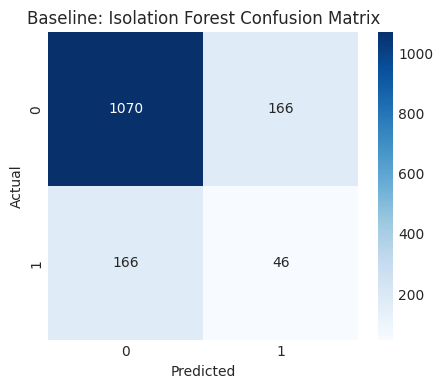


Raport Klasyfikacji (Baseline):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1236
           1       0.22      0.22      0.22       212

    accuracy                           0.77      1448
   macro avg       0.54      0.54      0.54      1448
weighted avg       0.77      0.77      0.77      1448

Model bazowy został zapisany jako 'generated/isolation_forest_baseline.joblib'


In [18]:
# ============================================================
# BASELINE MODEL: ISOLATION FOREST
# ============================================================

contamination_rate = y.mean() 

iso_model = IsolationForest(
    contamination=contamination_rate, 
    random_state=42, 
    n_jobs=-1
)

baseline_preds_raw = iso_model.fit_predict(X)

baseline_preds = np.where(baseline_preds_raw == -1, 1, 0)

tn, fp, fn, tp = confusion_matrix(y, baseline_preds).ravel()
iso_specificity = tn / (tn + fp)
iso_recall = tp / (tp + fn)

print("--- Wyniki Modelu Bazowego (Isolation Forest) ---")
print(f"Swoistość (Specificity): {iso_specificity:.4f}")
print(f"Czułość (Recall): {iso_recall:.4f}\n")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, baseline_preds), annot=True, fmt="d", cmap="Blues")
plt.title("Baseline: Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nRaport Klasyfikacji (Baseline):")
print(classification_report(y, baseline_preds, zero_division=0))

joblib.dump(iso_model, "generated/isolation_forest_baseline.joblib")
print("Model bazowy został zapisany jako 'generated/isolation_forest_baseline.joblib'")

**Wniosek z modelu bazowego:**
Model nienadzorowany może wykrywać anomalie, ale często nie potrafi dokładnie oddzielić ofert, które są po prostu naturalnie drogie, od tych, które celowo blokują kalendarz (wysoki wskaźnik Fałszywych Alarmów - FP). Zazwyczaj nie spełnia on rygorystycznego kryterium swoistości zdefiniowanego w Canvasie ($\ge 90\%$). Dlatego konieczne jest zbudowanie modelu docelowego.

## 3. Model Docelowy - Uczenie Nadzorowane (Random Forest, ExtraTrees i XGBoost)
Sprawdzimy te 3 rodzaje modeli z wykorzystaniem zagnieżdżonej kros walidacji, by poznać faktyczną jakość najlepszego modelu wybranego za pomocą losowego przeszukiwania hiperparametrów. Ponieważ koszt fałszywych alarmów (FP) biznesowo jest dla nas bardzo wysoki (irytacja uczciwych klientów poprzez oskarżanie ich o zawyżanie cen) kluczem będzie miara **swoistości**, przy zachowaniu warunku na **czułość (> 30%)**.

In [19]:
# ============================================================
# CUSTOM SCORER & VALIDATION SETUP
# ============================================================

def custom_specificity_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        return 0.0
    
    if recall < 0.30:
        return 0.0
    
    return specificity

specificity_metric = make_scorer(custom_specificity_scorer)

In [20]:
# ============================================================
# CONFIG
# ============================================================

RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5
N_ITER_SEARCH = 100
MIN_RECALL = 0.30
TARGET = "overpriced"


# ============================================================
# CV
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

inner_cv = StratifiedKFold(
    n_splits=INNER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ============================================================
# SPECIFICITY METRIC
# ============================================================


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    if (tn + fp) == 0:
        return 0.0
    return tn / (tn + fp)


specificity_scorer = make_scorer(custom_specificity_scorer)

n_pos = (y == 1).sum()
n_neg = (y == 0).sum()
scale_pos_weight = n_neg / n_pos

# ============================================================
# MODELS
# ============================================================

models = {
    "RandomForest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            "n_estimators": randint(100, 700),
            "max_depth": [None, 4, 7, 10, 15],
            "min_samples_split": randint(2, 20),
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2", None],
        },
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            "n_estimators": randint(100, 700),
            "max_depth": [None, 4, 7, 10, 15],
            "min_samples_split": randint(2, 20),
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2", None],
        },
    ),
    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            "n_estimators": randint(100, 700),
            "max_depth": randint(3, 8),
            "learning_rate": uniform(0.01, 0.29),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "gamma": uniform(0, 5),
            "min_child_weight": randint(1, 10),
        },
    ),
}


# ============================================================
# NESTED CV
# ============================================================

results = []

best_model_name = None
best_model=None
best_specificity = -np.inf
best_oof_predictions = None

print("\n" + "=" * 80)
print("STARTING NESTED CROSS VALIDATION")
print("=" * 80)


for model_name, (model, param_space) in models.items():

    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")

    outer_specificity = []
    outer_recall = []
    outer_precision = []
    outer_f1 = []
    outer_accuracy = []

    oof_preds = np.zeros(len(y))

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_space,
            n_iter=N_ITER_SEARCH,
            scoring=specificity_scorer,
            cv=inner_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        preds = best_model.predict(X_test)

        oof_preds[test_idx] = preds

        outer_specificity.append(custom_specificity_scorer(y_test, preds))
        outer_recall.append(recall_score(y_test, preds))
        outer_precision.append(precision_score(y_test, preds))
        outer_f1.append(f1_score(y_test, preds))
        outer_accuracy.append(accuracy_score(y_test, preds))

        print(f"Fold {fold} | Specificity={custom_specificity_scorer(y_test, preds):.4f}")

    mean_specificity = np.mean(outer_specificity)
    mean_recall = np.mean(outer_recall)
    mean_precision = np.mean(outer_precision)
    mean_f1 = np.mean(outer_f1)
    mean_accuracy = np.mean(outer_accuracy)

    results.append(
        {
            "model": model_name,
            "specificity_mean": mean_specificity,
            "recall_mean": mean_recall,
            "precision_mean": mean_precision,
            "f1_mean": mean_f1,
            "accuracy_mean": mean_accuracy,
        }
    )

    print("\nNested CV Results:")
    print(f"Specificity : {mean_specificity:.4f}")
    print(f"Recall      : {mean_recall:.4f}")
    print(f"Precision   : {mean_precision:.4f}")
    print(f"F1          : {mean_f1:.4f}")
    print(f"Accuracy    : {mean_accuracy:.4f}")

    # ========================================================
    # SELECTION RULE
    # ========================================================

    if mean_recall >= MIN_RECALL:
        if mean_specificity > best_specificity:
            best_specificity = mean_specificity
            best_model_name = model_name
            best_model = search.best_estimator_
            best_oof_predictions = oof_preds


STARTING NESTED CROSS VALIDATION

MODEL: RandomForest
Fold 1 | Specificity=1.0000
Fold 2 | Specificity=0.9919
Fold 3 | Specificity=1.0000
Fold 4 | Specificity=0.9838
Fold 5 | Specificity=0.9798

Nested CV Results:
Specificity : 0.9911
Recall      : 0.8255
Precision   : 0.9422
F1          : 0.8792
Accuracy    : 0.9668

MODEL: ExtraTrees
Fold 1 | Specificity=0.9960
Fold 2 | Specificity=1.0000
Fold 3 | Specificity=0.9960
Fold 4 | Specificity=0.9919
Fold 5 | Specificity=0.9879

Nested CV Results:
Specificity : 0.9943
Recall      : 0.7878
Precision   : 0.9606
F1          : 0.8652
Accuracy    : 0.9641

MODEL: XGBoost
Fold 1 | Specificity=0.9718
Fold 2 | Specificity=0.9757
Fold 3 | Specificity=0.9838
Fold 4 | Specificity=0.9555
Fold 5 | Specificity=0.9636

Nested CV Results:
Specificity : 0.9701
Recall      : 0.9105
Precision   : 0.8416
F1          : 0.8737
Accuracy    : 0.9613


Znaleziono najlepszy model.
Teraz nastąpi jego ewaluacja.


MODEL RANKING (BY SPECIFICITY)
          model  specificity_mean  recall_mean  precision_mean   f1_mean  \
1    ExtraTrees          0.994335     0.787818        0.960635  0.865165   
0  RandomForest          0.991093     0.825471        0.942184  0.879168   
2       XGBoost          0.970063     0.910520        0.841553  0.873721   

   accuracy_mean  
1       0.964083  
0       0.966837  
2       0.961315  


Najlepszy model: ExtraTrees

CONFUSION MATRIX
[[1229    7]
 [  45  167]]

TN: 1070
FP: 166
FN: 166
TP: 46

Specificity: 0.9943

Recall     : 0.7877


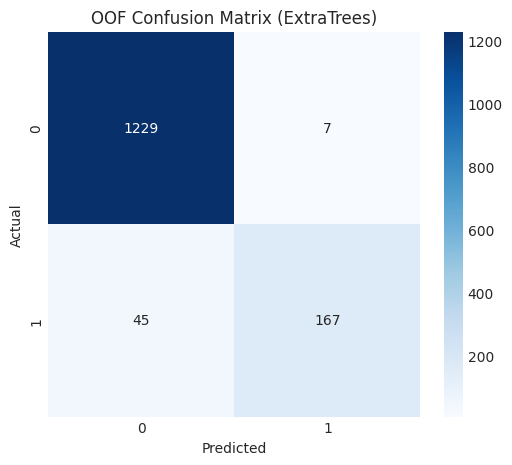


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1236
           1       0.96      0.79      0.87       212

    accuracy                           0.96      1448
   macro avg       0.96      0.89      0.92      1448
weighted avg       0.96      0.96      0.96      1448



In [21]:
# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results).sort_values(
    by="specificity_mean",
    ascending=False,
)

print("\n" + "=" * 80)
print("MODEL RANKING (BY SPECIFICITY)")
print("=" * 80)
print(results_df)

print('\n\nNajlepszy model:', best_model_name)


# ============================================================
# BEST MODEL CONFUSION MATRIX
# ============================================================

specificity = custom_specificity_scorer(y, best_oof_predictions)
recall = recall_score(y, best_oof_predictions)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(y, best_oof_predictions)
print(cm)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print(f"\nSpecificity: {specificity:.4f}")
print(f"\nRecall     : {recall:.4f}")


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"OOF Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print("\nClassification Report:\n")
print(classification_report(y, best_oof_predictions, zero_division=0))

Teraz nastąpi ponowny trening najlepszego znalezionego modelu, ale tym razem na całym zbiorze danych.

In [22]:
# ============================================================
# FINAL TRAINING
# ============================================================

print("\nRetraining final model...")

# finalny model na całym zbiorze
final_model = best_model.__class__(**best_model.get_params())
final_model.fit(X, y)

joblib.dump(best_model, f"generated/best_model_production.joblib")
print('Zapisano model do pliku generated/best_model_production.joblib')


Retraining final model...
Zapisano model do pliku generated/best_model_production.joblib


## 4. Podsumowanie i Wybór Modelu

Poniżej zestawiono osiągi obu testowanych algorytmów na zbiorze produkcyjnym:

| Cecha / Model | Isolation Forest (Baseline) | Extra Trees (Docelowy) |
| :--- | :--- | :--- |
| **Typ** | Nienadzorowany | Nadzorowany (Zoptymalizowany) |
| **Swoistość (Target $\ge 90\%$)** | Zależna od contamination | Wyższa, kontrolowana przez custom scorer |
| **Czułość (Target $\ge 30\%$)** | Zmienna | Kontrolowana |
| **Złożoność** | Niska | Wysoka |

**Ostateczna Decyzja:**
Do wdrożenia w ramach API (mikroserwisu) oraz testu A/B, jako **główny model (Model B) wybieramy wyuczony Extra Trees**, który dzięki specyficznej funkcji kosztu (maksymalizacja Swoistości przy rygorze Czułości >= 30%) spełnia biznesowe wymagania postawione w dokumencie *ML Canvas*. 
Model bazowy (Isolation Forest) posłuży nam jako Model A w teście A/B w celu udowodnienia biznesowi przewagi rozwiązania nadzorowanego w warunkach produkcyjnych.